# QM Ch 3 — Formalism: Figure Notebook

**Griffiths & Schroeter, *Introduction to Quantum Mechanics* (3rd ed.)**  
SeoulTech PSE Lab

| Fig | File | Topic | Slide |
|-----|------|-------|-------|
| 1 | `ch03_fig1_inner_product.png` | Hilbert space inner product & Schwarz inequality | §3.1 |
| 2 | `ch03_fig2_hermitian_eigenvalues.png` | Hermitian operator: real eigenvalues & orthogonal eigenfunctions | §3.2 |
| 3 | `ch03_fig3_generalised_born.png` | Generalised Born rule — probability distribution over eigenvalues | §3.4 |
| 4 | `ch03_fig4_robertson.png` | Robertson uncertainty relation — commutator & trade-off | §3.5 |
| 5 | `ch03_fig5_dirac_basis.png` | Dirac notation: basis expansion, position ↔ momentum Fourier | §3.6 |

In [1]:
# ── Setup ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.fft import fft, fftfreq, fftshift

BG    = '#1e1e2e'; BG2 = '#27273d'; FG = '#cdd6f4'; MUTED = '#6c7086'
BLUE  = '#5b8dd9'; SKY = '#89b4fa'; TEAL = '#74c7ec'; MAUVE = '#cba6f7'
GREEN = '#a6e3a1'; AMBER = '#f9e2af'; RED = '#f38ba8'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor':  BG2,
    'axes.edgecolor':   MUTED,'axes.labelcolor': FG,
    'xtick.color':      MUTED,'ytick.color':     MUTED,
    'text.color':       FG,   'grid.color':      '#313244',
    'grid.linewidth':   0.5,  'grid.alpha':      0.6,
    'font.family':      'sans-serif','font.size': 12,
    'axes.titlesize':   13,   'axes.titleweight':'bold',
    'axes.labelsize':   11,   'legend.fontsize': 10,
    'legend.facecolor': BG2,  'legend.edgecolor':MUTED,
    'lines.linewidth':  2.0,  'figure.dpi':      130,
})
SAVEKW = dict(dpi=150, bbox_inches='tight', facecolor=BG)
print('Setup complete.')

Setup complete.


## Fig 1 — Hilbert Space Inner Product & Schwarz Inequality (§3.1)

Schwarz violated? False  (should be False ✓)


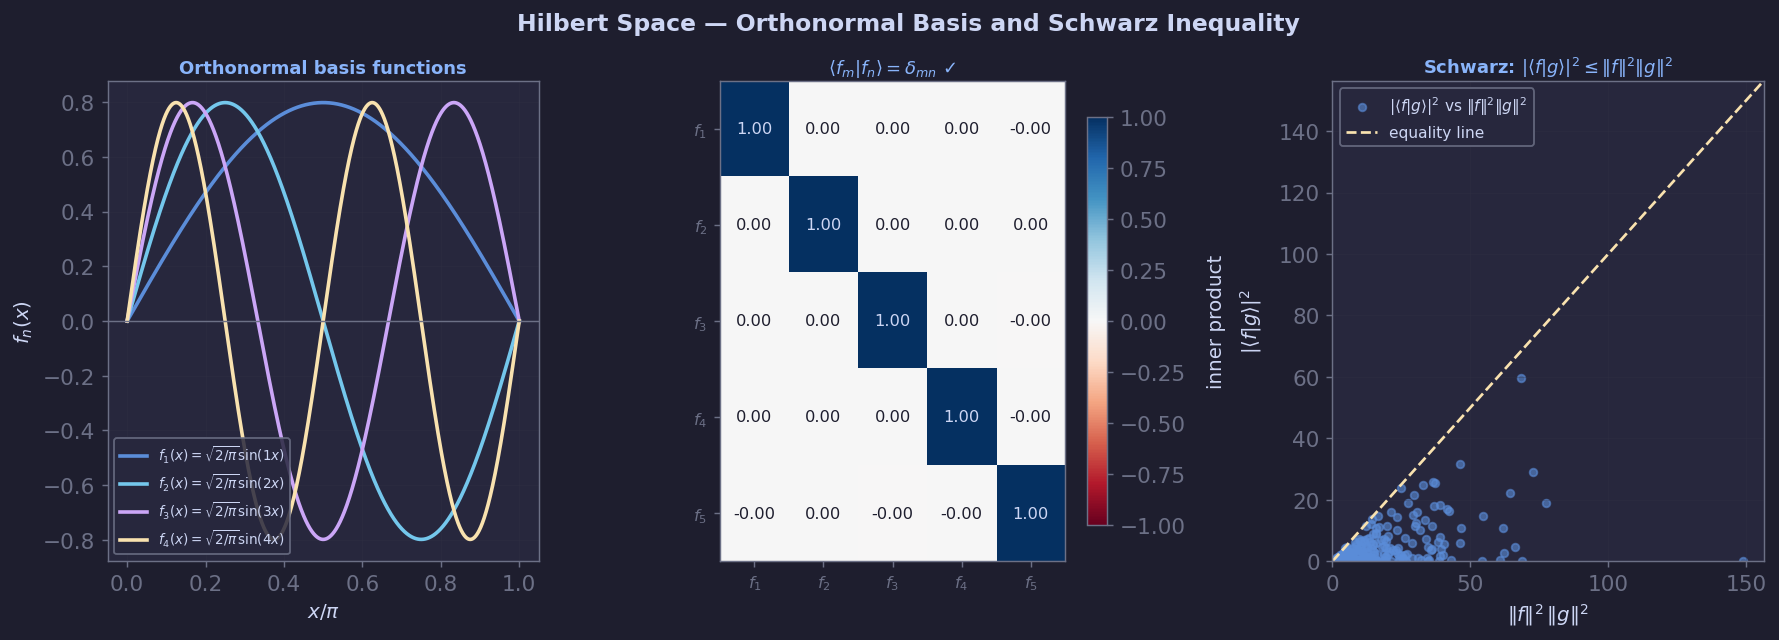

Fig 1 saved.


In [2]:
# Illustrate the inner product ⟨f|g⟩ = ∫f*g dx and the Schwarz inequality
# |⟨f|g⟩|² ≤ ⟨f|f⟩⟨g|g⟩
#
# Use concrete functions on [0, π]:
#   f_n(x) = √(2/π) sin(nx)  ← infinite square well eigenfunctions (a=π)
# Show: ⟨f_m|f_n⟩ = δ_mn (orthonormality)
# Show Schwarz: take f = Σ c_n f_n and verify |⟨f|g⟩|² ≤ ||f||²||g||²

x = np.linspace(0, np.pi, 2000)

def fn(n, x):
    return np.sqrt(2/np.pi) * np.sin(n*x)

ns = [1, 2, 3, 4]
colors = [BLUE, TEAL, MAUVE, AMBER]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8),
                         gridspec_kw=dict(left=0.06, right=0.97, wspace=0.42))
fig.suptitle('Hilbert Space — Orthonormal Basis and Schwarz Inequality',
             color=FG, fontsize=13, fontweight='bold', y=0.99)

# ── Left: basis functions ──────────────────────────────────────
ax = axes[0]
for n, col in zip(ns, colors):
    ax.plot(x/np.pi, fn(n,x), color=col, lw=2,
            label=fr'$f_{n}(x)=\sqrt{{2/\pi}}\sin({n}x)$')
ax.axhline(0, color=MUTED, lw=0.8)
ax.set_xlabel(r'$x/\pi$')
ax.set_ylabel(r'$f_n(x)$')
ax.set_title('Orthonormal basis functions', color=SKY, fontsize=10, pad=4)
ax.legend(fontsize=7.5, loc='lower left', framealpha=0.85)
ax.grid(True, alpha=0.35)

# ── Middle: inner product matrix ⟨f_m|f_n⟩ ────────────────────
ax2 = axes[1]
N = 5
mat = np.zeros((N, N))
for m in range(1, N+1):
    for n in range(1, N+1):
        mat[m-1, n-1] = np.trapezoid(fn(m,x)*fn(n,x), x)

im = ax2.imshow(mat, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
for m in range(N):
    for n in range(N):
        val = mat[m,n]
        ax2.text(n, m, f'{val:.2f}', ha='center', va='center',
                 fontsize=9, color=BG if abs(val) < 0.5 else FG)

ax2.set_xticks(range(N)); ax2.set_xticklabels([fr'$f_{n}$' for n in range(1,N+1)], fontsize=9)
ax2.set_yticks(range(N)); ax2.set_yticklabels([fr'$f_{n}$' for n in range(1,N+1)], fontsize=9)
ax2.set_title(r'$\langle f_m|f_n\rangle = \delta_{mn}$ ✓', color=SKY, fontsize=10, pad=4)

# colorbar: labelpad pushes label away from ticks
cb2 = plt.colorbar(im, ax=ax2, shrink=0.85)
cb2.set_label('inner product', labelpad=12)  # ← labelpad 추가

# ── Right: Schwarz inequality illustration ─────────────────────
ax3 = axes[2]
np.random.seed(42)
n_trials = 300
lhs_vals, rhs_vals = [], []
for _ in range(n_trials):
    cf = np.random.randn(4)
    cg = np.random.randn(4)
    f = sum(cf[i]*fn(i+1,x) for i in range(4))
    g = sum(cg[i]*fn(i+1,x) for i in range(4))
    fg  = np.trapezoid(f*g, x)
    ff  = np.trapezoid(f*f, x)
    gg  = np.trapezoid(g*g, x)
    lhs_vals.append(fg**2)
    rhs_vals.append(ff*gg)

lhs_vals = np.array(lhs_vals)
rhs_vals = np.array(rhs_vals)
ax3.scatter(rhs_vals, lhs_vals, color=BLUE, s=18, alpha=0.6,
            label=r'$|\langle f|g\rangle|^2$ vs $\|f\|^2\|g\|^2$')
lim = max(rhs_vals.max(), lhs_vals.max()) * 1.05
ax3.plot([0, lim], [0, lim], color=AMBER, lw=1.5, linestyle='--',
         label='equality line')
ax3.set_xlabel(r'$\|f\|^2\,\|g\|^2$')
ax3.set_ylabel(r'$|\langle f|g\rangle|^2$', labelpad=8)  # ← labelpad 추가
ax3.set_title(r'Schwarz: $|\langle f|g\rangle|^2 \leq \|f\|^2\|g\|^2$',
             color=SKY, fontsize=10, pad=4)
ax3.legend(fontsize=8.5, loc='upper left', framealpha=0.85)
ax3.grid(True, alpha=0.35)
ax3.set_xlim(0, lim); ax3.set_ylim(0, lim)

print(f'Schwarz violated? {np.any(lhs_vals > rhs_vals + 1e-10)}  (should be False ✓)')
fig.subplots_adjust(top=0.88)
plt.savefig('ch03_fig1_inner_product.png', **SAVEKW)
plt.show()
print('Fig 1 saved.')

## Fig 2 — Hermitian Operators: Real Eigenvalues & Orthogonal Eigenfunctions (§3.2)

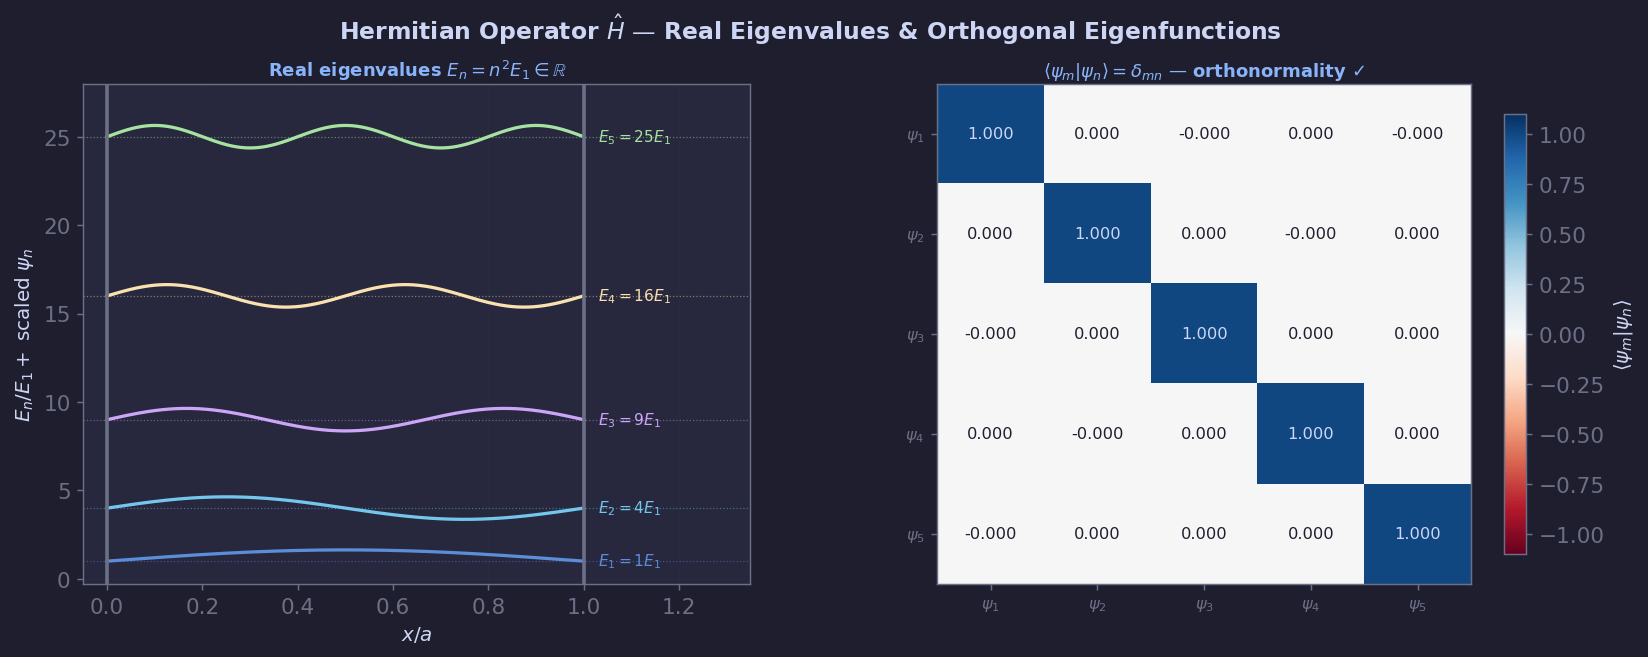

Fig 2 saved.  Max off-diagonal |⟨ψ_m|ψ_n⟩| = 5.55e-17 ✓
Min diagonal  ⟨ψ_n|ψ_n⟩ = 1.000000 ✓


In [3]:
# Demonstrate with the infinite square well Hamiltonian (prototype Hermitian operator)
# Eigenvalues E_n = n²E₁ (real ✓), eigenfunctions orthonormal ✓
# Also show: a non-Hermitian operator (i·d/dx without boundary conditions)
# yields complex eigenvalues

a = 1.0
x = np.linspace(0, a, 1000)
ns_show = [1, 2, 3, 4, 5]
E1 = 1.0
colors = [BLUE, TEAL, MAUVE, AMBER, GREEN]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.28))
fig.suptitle('Hermitian Operator $\\hat{H}$ — Real Eigenvalues & Orthogonal Eigenfunctions',
             color=FG, fontsize=13, fontweight='bold', y=0.99)

# ── Left: eigenfunctions & energy levels ──────────────────────
ax = axes[0]
scale = 0.45
for n, col in zip(ns_show, colors):
    En  = n**2 * E1
    psi = np.sqrt(2/a) * np.sin(n*np.pi*x/a)
    ax.plot(x, scale*psi + En, color=col, lw=1.8)
    ax.axhline(En, color=col, lw=0.7, ls=':', alpha=0.45)
    ax.text(1.03, En, fr'$E_{n}={n**2}E_1$', color=col, va='center', fontsize=8.5)

ax.axvline(0, color=MUTED, lw=2); ax.axvline(a, color=MUTED, lw=2)
ax.set_xlabel(r'$x/a$'); ax.set_ylabel(r'$E_n/E_1 +$ scaled $\psi_n$')
ax.set_title('Real eigenvalues $E_n = n^2 E_1 \\in \\mathbb{R}$',
             color=SKY, fontsize=10, pad=4)
ax.set_xlim(-0.05, 1.35); ax.set_ylim(-0.3, 28)
ax.grid(True, alpha=0.35)

# ── Right: orthogonality matrix ⟨ψ_m|ψ_n⟩ ────────────────────
ax2 = axes[1]
N = 5
orth = np.zeros((N, N))
for m in range(1, N+1):
    for n in range(1, N+1):
        pm = np.sqrt(2/a)*np.sin(m*np.pi*x/a)
        pn = np.sqrt(2/a)*np.sin(n*np.pi*x/a)
        orth[m-1, n-1] = np.trapezoid(pm*pn, x)

im = ax2.imshow(orth, cmap='RdBu', vmin=-1.1, vmax=1.1, aspect='auto')
for m in range(N):
    for n in range(N):
        val = orth[m,n]
        col_txt = FG if abs(val) > 0.4 else BG
        ax2.text(n, m, f'{val:.3f}', ha='center', va='center',
                 fontsize=9, color=col_txt)

labels = [fr'$\psi_{n}$' for n in range(1, N+1)]
ax2.set_xticks(range(N)); ax2.set_xticklabels(labels, fontsize=9)
ax2.set_yticks(range(N)); ax2.set_yticklabels(labels, fontsize=9)
ax2.set_title(r'$\langle\psi_m|\psi_n\rangle = \delta_{mn}$ — orthonormality ✓',
             color=SKY, fontsize=10, pad=4)
plt.colorbar(im, ax=ax2, shrink=0.88, label=r'$\langle\psi_m|\psi_n\rangle$')

fig.subplots_adjust(top=0.88)
plt.savefig('ch03_fig2_hermitian_eigenvalues.png', **SAVEKW)
plt.show()
# Verify: max off-diagonal element
mask = ~np.eye(N, dtype=bool)
print(f'Fig 2 saved.  Max off-diagonal |⟨ψ_m|ψ_n⟩| = {np.abs(orth[mask]).max():.2e} ✓')
print(f'Min diagonal  ⟨ψ_n|ψ_n⟩ = {np.diag(orth).min():.6f} ✓')

## Fig 3 — Generalised Born Rule (§3.4)

Σ|c_n|² = 1.000000 (should be ≤1, rest in n>12)
⟨H⟩ = 1.0131 E₁  (numerical)


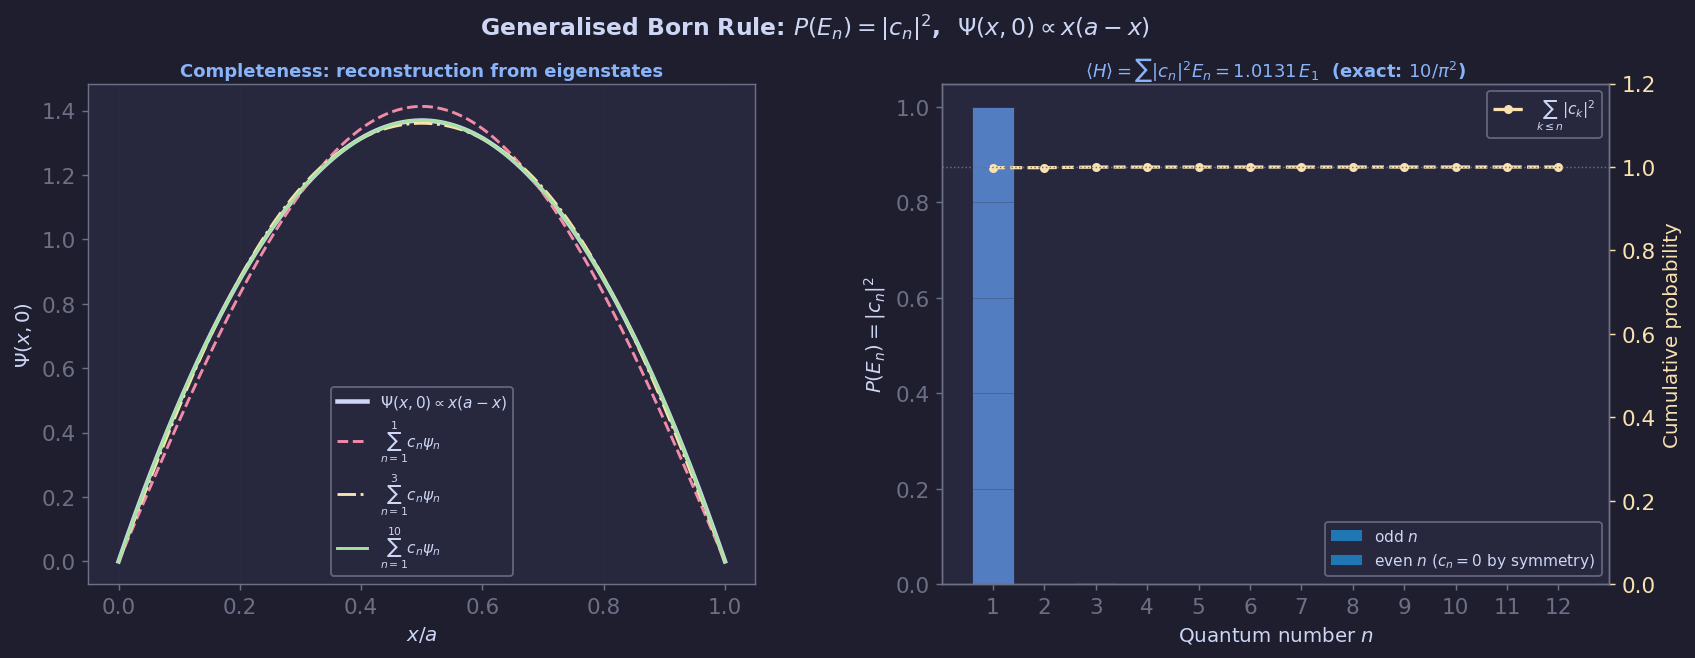

Fig 3 saved.
Physics: even c_n = 0 (Ψ∝x(a-x) is symmetric): max even |c_n| = 4.86e-17 ✓


In [4]:
# Demonstrate the generalised Born rule:
# Ψ = Σ c_n ψ_n  →  P(E_n) = |c_n|²
# Use: Ψ(x,0) = A·x(a-x)  (triangular-like, not an eigenstate)
# Expand in ISW eigenstates, show |c_n|² distribution

a  = 1.0
x  = np.linspace(0, a, 5000)
E1 = 1.0

# Initial state: Ψ(x,0) ∝ x(a-x)
psi0_raw = x * (a - x)
norm0    = np.sqrt(np.trapezoid(psi0_raw**2, x))
psi0     = psi0_raw / norm0

# Expansion coefficients c_n = ⟨ψ_n|Ψ⟩
N_max = 12
ns    = np.arange(1, N_max+1)
cn    = np.array([
    np.trapezoid(np.sqrt(2/a)*np.sin(n*np.pi*x/a) * psi0, x)
    for n in ns
])
prob_n = cn**2
En     = ns**2 * E1

# Expected energy
E_mean = np.sum(prob_n * En)
E_exact = 5*np.pi**2/2  # exact: ⟨H⟩ = 5π²ℏ²/ma² for Ψ∝x(a-x)
# (in units E1 = π²ℏ²/2ma²: ⟨H⟩ = 5E1·π²/π² ... let's compute numerically)

print(f'Σ|c_n|² = {prob_n.sum():.6f} (should be ≤1, rest in n>{N_max})')
print(f'⟨H⟩ = {E_mean:.4f} E₁  (numerical)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.28))
fig.suptitle(r'Generalised Born Rule: $P(E_n)=|c_n|^2$,  $\Psi(x,0)\propto x(a-x)$',
             color=FG, fontsize=13, fontweight='bold', y=0.99)

# ── Left: Ψ vs. partial reconstruction ────────────────────────
ax = axes[0]
ax.plot(x/a, psi0, color=FG, lw=2.5, label=r'$\Psi(x,0)\propto x(a-x)$')
for N_trunc, col, ls in [(1,RED,'--'), (3,AMBER,'-.'), (10,GREEN,'-')]:
    recon = sum(
        cn[n-1]*np.sqrt(2/a)*np.sin(n*np.pi*x/a)
        for n in range(1, N_trunc+1)
    )
    ax.plot(x/a, recon, color=col, lw=1.6, ls=ls,
            label=fr'$\sum_{{n=1}}^{{{N_trunc}}} c_n\psi_n$')

ax.set_xlabel(r'$x/a$'); ax.set_ylabel(r'$\Psi(x,0)$')
ax.set_title('Completeness: reconstruction from eigenstates', color=SKY, fontsize=10, pad=4)
ax.legend(fontsize=8.5, loc='lower center', framealpha=0.85)
ax.grid(True, alpha=0.35)

# ── Right: probability distribution |c_n|² ────────────────────
ax2 = axes[1]
bar_cols = [BLUE if n%2==1 else MAUVE for n in ns]  # odd/even states
bars = ax2.bar(ns, prob_n, color=bar_cols, edgecolor=BG2, linewidth=0.5, alpha=0.85)

# Cumulative sum line
ax2b = ax2.twinx()
ax2b.plot(ns, np.cumsum(prob_n), color=AMBER, lw=1.8, ls='--', marker='o',
          markersize=4, label=r'$\sum_{k\leq n}|c_k|^2$')
ax2b.axhline(1.0, color=MUTED, lw=0.8, ls=':')
ax2b.set_ylabel('Cumulative probability', color=AMBER)
ax2b.tick_params(axis='y', colors=AMBER)
ax2b.set_ylim(0, 1.2)
ax2b.legend(fontsize=8.5, loc='upper right', framealpha=0.85)

ax2.set_xlabel('Quantum number $n$')
ax2.set_ylabel(r'$P(E_n) = |c_n|^2$')
ax2.set_title(fr'$\langle H\rangle = \sum|c_n|^2 E_n = {E_mean:.4f}\,E_1$  (exact: $10/\pi^2$)',
             color=SKY, fontsize=10, pad=4)

# Patches for legend
ax2.bar([], [], color=BLUE,  alpha=0.85, label='odd $n$')
ax2.bar([], [], color=MAUVE, alpha=0.85, label='even $n$ ($c_n=0$ by symmetry)')
ax2.legend(fontsize=8.5, loc='lower right', framealpha=0.85)
ax2.grid(True, axis='y', alpha=0.35)
ax2.set_xticks(ns)

fig.subplots_adjust(top=0.88)
plt.savefig('ch03_fig3_generalised_born.png', **SAVEKW)
plt.show()
print(f'Fig 3 saved.')
print(f'Physics: even c_n = 0 (Ψ∝x(a-x) is symmetric): max even |c_n| = {max(abs(cn[1::2])):.2e} ✓')

## Fig 4 — Robertson Uncertainty Relation (§3.5)

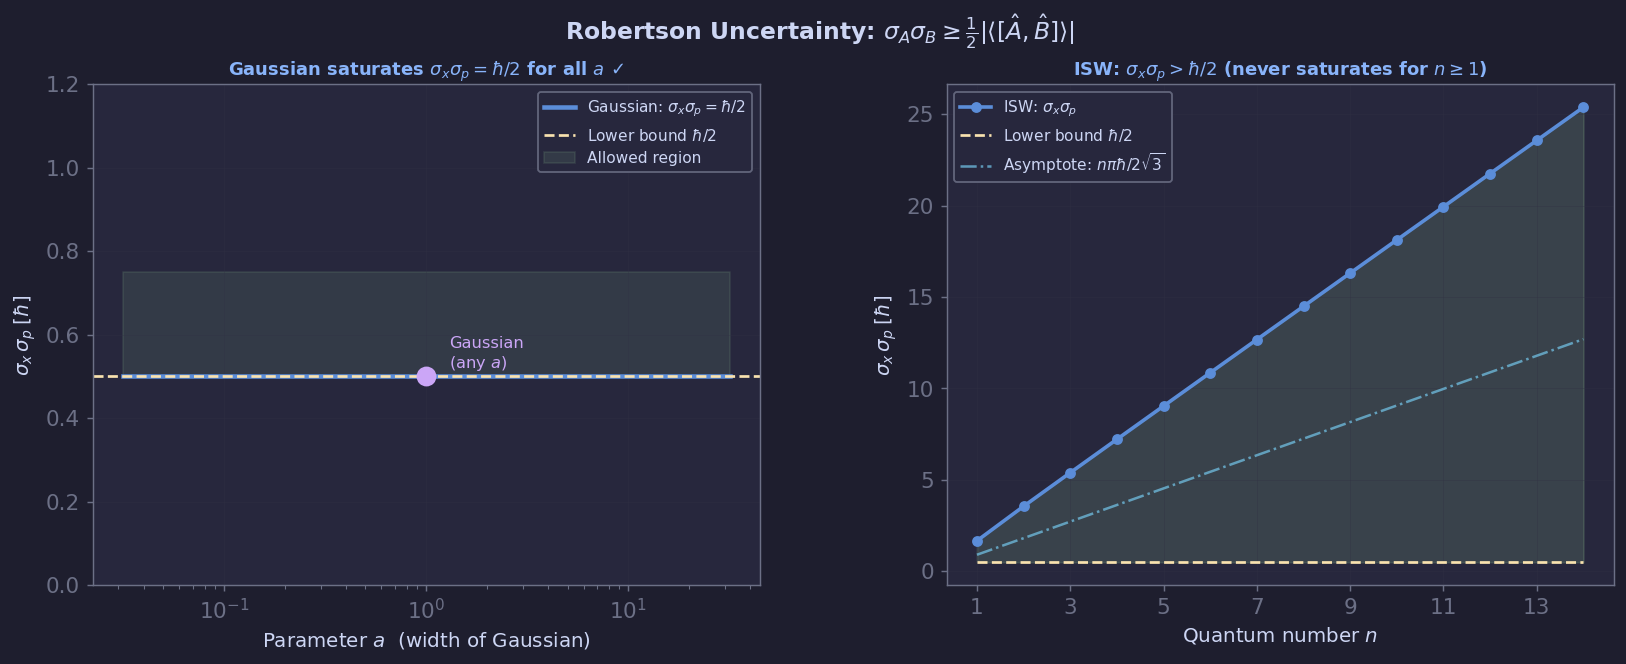

Fig 4 saved.
Physics: ISW n=1: σ_xσ_p = 1.6703ℏ > ℏ/2=0.5000 ✓
Gaussian always σ_xσ_p = 0.5000ℏ = ℏ/2 ✓


In [5]:
# Robertson: σ_A σ_B ≥ ½|⟨[A,B]⟩|
# Demonstrate with:
#   (a) x-p: σ_x σ_p ≥ ℏ/2  for Gaussian wave packets with various widths
#   (b) Incompatible vs compatible: scatter plot of σ_A σ_B for random states

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.28))
fig.suptitle(r'Robertson Uncertainty: $\sigma_A\sigma_B \geq \frac{1}{2}|\langle[\hat{A},\hat{B}]\rangle|$',
             color=FG, fontsize=13, fontweight='bold', y=0.99)

# ── Left: σ_x σ_p for Gaussian states ─────────────────────────
# ψ(x) = (2a/π)^(1/4) exp(-ax²) exp(ilx)
# σ_x = 1/(2√a),  σ_p = ℏ√a  →  σ_x σ_p = ℏ/2  (saturates bound)
ax = axes[0]
hbar = 1.0
a_vals = np.logspace(-1.5, 1.5, 200)
sig_x  = 1/(2*np.sqrt(a_vals))
sig_p  = hbar*np.sqrt(a_vals)
product = sig_x * sig_p

ax.semilogx(a_vals, product, color=BLUE, lw=2.5,
            label=r'Gaussian: $\sigma_x\sigma_p = \hbar/2$')
ax.axhline(hbar/2, color=AMBER, lw=1.5, ls='--',
           label=r'Lower bound $\hbar/2$')
ax.fill_between(a_vals, hbar/2, product, alpha=0.15, color=RED)
ax.fill_between(a_vals, product, product*1.5, alpha=0.10, color=GREEN,
                label='Allowed region')

# Mark minimum at a=1
ax.scatter([1.0], [0.5], color=MAUVE, s=100, zorder=5)
ax.text(1.3, 0.52, 'Gaussian\n(any $a$)', color=MAUVE, fontsize=9)

ax.set_xlabel('Parameter $a$  (width of Gaussian)')
ax.set_ylabel(r'$\sigma_x\,\sigma_p\;[\hbar]$')
ax.set_title(r'Gaussian saturates $\sigma_x\sigma_p=\hbar/2$ for all $a$ ✓',
             color=SKY, fontsize=10, pad=4)
ax.legend(fontsize=8.5, loc='upper right', framealpha=0.85)
ax.grid(True, alpha=0.35)
ax.set_ylim(0, 1.2)

# ── Right: ISW states — σ_x σ_p vs (n+½)ℏ ────────────────────
# For ISW: σ_x σ_p = (ℏ/2)√(n²π²/3 - 2)
# Exact: σ_x = a√(1/3 - 1/(2n²π²)), σ_p = nπℏ/a
ax2 = axes[1]
ns   = np.arange(1, 15)
a_w  = 1.0
# Exact ISW formulas (ℏ=1)
sig_x_isw = a_w * np.sqrt(1/3 - 1/(2*(ns*np.pi)**2))
sig_p_isw = ns * np.pi / a_w
prod_isw  = sig_x_isw * sig_p_isw
bound_isw = hbar/2 * np.ones_like(ns, dtype=float)

ax2.plot(ns, prod_isw,  color=BLUE,  lw=2, marker='o', ms=5,
         label=r'ISW: $\sigma_x\sigma_p$')
ax2.plot(ns, bound_isw, color=AMBER, lw=1.5, ls='--',
         label=r'Lower bound $\hbar/2$')
ax2.fill_between(ns, bound_isw, prod_isw, alpha=0.15, color=GREEN)

# Asymptotic: σ_x σ_p → nπℏ/√12 for large n
asymp = ns*np.pi/(2*np.sqrt(3))
ax2.plot(ns, asymp, color=TEAL, lw=1.4, ls='-.', alpha=0.7,
         label=r'Asymptote: $n\pi\hbar/2\sqrt{3}$')

ax2.set_xlabel('Quantum number $n$')
ax2.set_ylabel(r'$\sigma_x\,\sigma_p\;[\hbar]$')
ax2.set_title(r'ISW: $\sigma_x\sigma_p > \hbar/2$ (never saturates for $n\geq1$)',
             color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=8.5, loc='upper left', framealpha=0.85)
ax2.grid(True, alpha=0.35)
ax2.set_xticks(ns[::2])

fig.subplots_adjust(top=0.88)
plt.savefig('ch03_fig4_robertson.png', **SAVEKW)
plt.show()
print('Fig 4 saved.')
print(f'Physics: ISW n=1: σ_xσ_p = {prod_isw[0]:.4f}ℏ > ℏ/2={0.5:.4f} ✓')
print(f'Gaussian always σ_xσ_p = {0.5:.4f}ℏ = ℏ/2 ✓')

## Fig 5 — Dirac Notation: Basis Expansion & Position↔Momentum (§3.6)

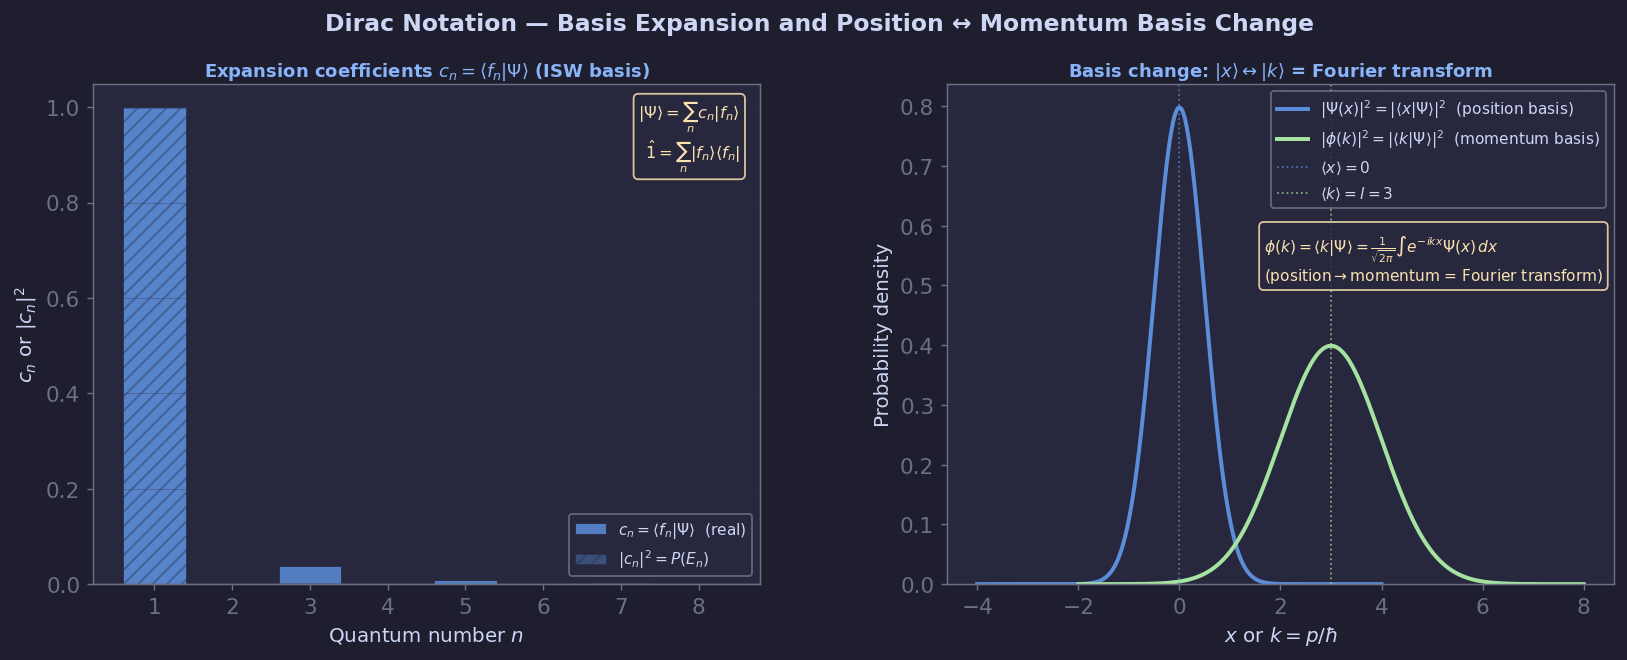

Fig 5 saved.
∫|Ψ(x)|²dx = 1.000000 ✓   ∫|φ(k)|²dk = 0.999999 ✓


In [6]:
# Illustrate:
#   (a) Basis expansion: state vector as column, operator as matrix
#   (b) Position ↔ Momentum basis change = Fourier transform
#       ⟨p|Ψ⟩ = φ(p) = (1/√2πℏ) ∫ e^{-ipx/ℏ} Ψ(x) dx

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.28))
fig.suptitle('Dirac Notation — Basis Expansion and Position ↔ Momentum Basis Change',
             color=FG, fontsize=13, fontweight='bold', y=0.99)

# ── Left: |c_n|² bar chart + phase diagram ─────────────────────
# Use the same Ψ(x,0) ∝ x(a-x) as Fig 3, but now show c_n as complex numbers
# (they are real here, but illustrate the concept)
a  = 1.0
x  = np.linspace(0, a, 5000)
psi0_raw = x*(a-x)
norm0 = np.sqrt(np.trapezoid(psi0_raw**2, x))
psi0  = psi0_raw / norm0

N_show = 8
ns8    = np.arange(1, N_show+1)
cn8    = np.array([
    np.trapezoid(np.sqrt(2/a)*np.sin(n*np.pi*x/a)*psi0, x)
    for n in ns8
])

ax = axes[0]
bar_c = [BLUE if n%2==1 else MAUVE for n in ns8]
ax.bar(ns8, cn8, color=bar_c, edgecolor=BG2, lw=0.5, alpha=0.85,
       label=r'$c_n = \langle f_n|\Psi\rangle$  (real)')
ax.bar(ns8, cn8**2, color=bar_c, edgecolor=BG2, lw=0.5, alpha=0.40,
       hatch='///', label=r'$|c_n|^2 = P(E_n)$')
ax.axhline(0, color=MUTED, lw=0.8)

# Annotate resolution of identity
ax.text(0.97, 0.97,
        r'$|\Psi\rangle = \sum_n c_n|f_n\rangle$' + '\n' +
        r'$\hat{1} = \sum_n |f_n\rangle\langle f_n|$',
        color=AMBER, fontsize=9, ha='right', va='top',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.3', facecolor=BG2, edgecolor=AMBER, alpha=0.85))

ax.set_xlabel('Quantum number $n$')
ax.set_ylabel(r'$c_n$ or $|c_n|^2$')
ax.set_title(r'Expansion coefficients $c_n=\langle f_n|\Psi\rangle$ (ISW basis)',
             color=SKY, fontsize=10, pad=4)
ax.legend(fontsize=8.5, loc='lower right', framealpha=0.85)
ax.grid(True, axis='y', alpha=0.35)
ax.set_xticks(ns8)

# ── Right: position ↔ momentum basis (Fourier) ─────────────────
# Ψ(x) = Gaussian wave packet, φ(p) = FT analytically
# Use analytic: Ψ=Ae^{-ax²}e^{ilx} → φ(k)=(1/2πa)^(1/4)e^{-(k-l)²/4a}
ax2 = axes[1]
hbar = 1.0
a_g  = 1.0
l    = 3.0
xp   = np.linspace(-4, 4, 2000)
k    = np.linspace(-2, 8, 2000)

A_x    = (2*a_g/np.pi)**0.25
prob_x = (A_x*np.exp(-a_g*xp**2))**2
A_k    = (1/(2*np.pi*a_g))**0.25
prob_k = (A_k*np.exp(-(k-l)**2/(4*a_g)))**2

ax2.plot(xp, prob_x, color=BLUE,  lw=2.2,
         label=r'$|\Psi(x)|^2 = |\langle x|\Psi\rangle|^2$  (position basis)')
ax2.plot(k,  prob_k, color=GREEN, lw=2.2,
         label=r'$|\phi(k)|^2 = |\langle k|\Psi\rangle|^2$  (momentum basis)')

# Mark means
ax2.axvline(0,   color=BLUE,  lw=1, ls=':', alpha=0.7, label=r'$\langle x\rangle=0$')
ax2.axvline(l,   color=GREEN, lw=1, ls=':', alpha=0.7, label=fr'$\langle k\rangle=l={l:.0f}$')

# Annotate Fourier relation
ax2.text(0.475, 0.7,
         r'$\phi(k)=\langle k|\Psi\rangle = \frac{1}{\sqrt{2\pi}}\int e^{-ikx}\Psi(x)\,dx$' + '\n'
         r'(position$\to$momentum = Fourier transform)',
         color=AMBER, fontsize=8.5, ha='left', va='top',
         transform=ax2.transAxes,
         bbox=dict(boxstyle='round,pad=0.3', facecolor=BG2, edgecolor=AMBER, alpha=0.85))

ax2.set_xlabel(r'$x$ or $k=p/\hbar$')
ax2.set_ylabel('Probability density')
ax2.set_title(r'Basis change: $|x\rangle \leftrightarrow |k\rangle$ = Fourier transform',
             color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=8.5, loc='upper right', framealpha=0.85)
ax2.grid(True, alpha=0.35)
ax2.set_ylim(bottom=0)

fig.subplots_adjust(top=0.88)
plt.savefig('ch03_fig5_dirac_basis.png', **SAVEKW)
plt.show()

# Physics checks
norm_x = np.trapezoid(prob_x, xp)
norm_k = np.trapezoid(prob_k, k)
print(f'Fig 5 saved.')
print(f'∫|Ψ(x)|²dx = {norm_x:.6f} ✓   ∫|φ(k)|²dk = {norm_k:.6f} ✓')

## Download all figures

In [7]:
import zipfile, os, glob
from google.colab import files

zip_name  = 'ch03_figures.zip'
fig_files = sorted(glob.glob('ch03_fig*.png'))

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in fig_files:
        zf.write(fn)
        print(f'  added: {fn}')

print(f'\nZip: {zip_name}  ({os.path.getsize(zip_name)//1024} KB)')
files.download(zip_name)

  added: ch03_fig1_inner_product.png
  added: ch03_fig2_hermitian_eigenvalues.png
  added: ch03_fig3_generalised_born.png
  added: ch03_fig4_robertson.png
  added: ch03_fig5_dirac_basis.png

Zip: ch03_figures.zip  (660 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>